In [ ]:
#  Core Libraries
!pip install -q numpy pandas matplotlib tqdm

#  Audio Processing
!pip install -q librosa soundfile

#  Machine Learning + DL
!pip install -q tensorflow scikit-learn keras-tuner


In [3]:
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
from tqdm import tqdm


# === Constants ===
SR = 22050
N_MELS = 256
FMAX = 8000
FIXED_TIME_STEPS = 150
SEED = 42
np.random.seed(SEED)

# === Paths ===
BASE_DIR = ""
AUDIO_DIR = "dataset/Train"
CSV_PATH = "dataset/Train.csv"
CACHE_DIR = os.path.join(BASE_DIR, "dataset/mel_cache")

# Make cache dir
os.makedirs(CACHE_DIR, exist_ok=True)

# === Load metadata
df = pd.read_csv(CSV_PATH)
df["filepath"] = df["file_name"].apply(lambda x: os.path.join(AUDIO_DIR, x))
df.head()


,file_name,classID,filepath
0,data_0.wav,3,dataset/Train\data_0.wav
1,data_1.wav,3,dataset/Train\data_1.wav
2,data_2.wav,3,dataset/Train\data_2.wav
3,data_3.wav,3,dataset/Train\data_3.wav
4,data_4.wav,6,dataset/Train\data_4.wav


In [2]:
def mel_cache_audio(df, filepath_col="filepath", add_to_df=True):
    """
    Caches mel spectrograms for each file in the dataframe.
    Skips if already cached. Optionally adds 'mel_path' column to df.
    
    Enhancements:
    - Logs with tqdm.write() to avoid breaking progress bar
    - Checks if file exists before attempting to load
    - Verifies sample rate matches SR
    - Optionally updates DataFrame with path to cached mel file
    """
    created, skipped, failed = 0, 0, 0
    mel_paths = []

    for _, row in tqdm(df.iterrows(), total=len(df), desc="📦 Caching mel spectrograms"):
        wav_path = row[filepath_col]
        out_path = os.path.join(CACHE_DIR, os.path.basename(wav_path).replace(".wav", "_mel.npy"))
        mel_paths.append(out_path)

        # Skip if already cached
        if os.path.exists(out_path):
            skipped += 1
            continue

        # Check if file exists
        if not os.path.exists(wav_path):
            tqdm.write(f"[ Missing] {wav_path}")
            failed += 1
            continue

        try:
            y, sr = librosa.load(wav_path, sr=SR)
            if sr != SR:
                tqdm.write(f"[ SR mismatch] {wav_path} → sr={sr}, expected {SR}")
            
            # Generate mel spectrogram
            mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS, fmax=FMAX)
            mel_db = librosa.power_to_db(mel, ref=np.max)
            mel_db = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-8)
            mel_db = librosa.util.fix_length(mel_db, size=FIXED_TIME_STEPS, axis=1)
            mel_db = np.expand_dims(mel_db, axis=-1)

            np.save(out_path, mel_db)
            created += 1

        except Exception as e:
            tqdm.write(f"[ Error] Skipping {wav_path}: {e}")
            failed += 1

    tqdm.write(f"\n Done. Created: {created}, Skipped: {skipped}, Failed: {failed}")

    if add_to_df:
        df["mel_path"] = mel_paths

    return df if add_to_df else None


In [3]:
df = mel_cache_audio(df)
df.head()

📦 Caching mel spectrograms: 100%|██████████| 7057/7057 [00:00<00:00, 22119.99it/s]


 Done. Created: 0, Skipped: 7057, Failed: 0


,file_name,classID,filepath,mel_path
0,data_0.wav,3,/kaggle/input/yldz-teknik-proje-1-train-datase...,/kaggle/working/mel_cache/data_0_mel.npy
1,data_1.wav,3,/kaggle/input/yldz-teknik-proje-1-train-datase...,/kaggle/working/mel_cache/data_1_mel.npy
2,data_2.wav,3,/kaggle/input/yldz-teknik-proje-1-train-datase...,/kaggle/working/mel_cache/data_2_mel.npy
3,data_3.wav,3,/kaggle/input/yldz-teknik-proje-1-train-datase...,/kaggle/working/mel_cache/data_3_mel.npy
4,data_4.wav,6,/kaggle/input/yldz-teknik-proje-1-train-datase...,/kaggle/working/mel_cache/data_4_mel.npy


In [4]:
def inspect_cached_mels(df, n=5):
    print(f"\n📂 Inspecting {n} random cached mels:")
    sample_files = df.sample(n, random_state=np.random.randint(9999))
    
    for _, row in sample_files.iterrows():
        mel_path = os.path.join(
            CACHE_DIR, os.path.basename(row["filepath"]).replace(".wav", "_mel.npy")
        )
        try:
            mel = np.load(mel_path)
            print(f"✅ {mel_path}")
            print(f"  - Shape     : {mel.shape}")
            print(f"  - Min/Max   : {mel.min():.3f} / {mel.max():.3f}")
            print(f"  - Nonzero % : {np.count_nonzero(mel) / mel.size * 100:.2f}%")
        except Exception as e:
            print(f"❌ {mel_path} failed to load: {e}")


In [5]:
inspect_cached_mels(df)


📂 Inspecting 5 random cached mels:
✅ /kaggle/working/mel_cache/data_4218_mel.npy
  - Shape     : (256, 150, 1)
  - Min/Max   : 0.000 / 1.000
  - Nonzero % : 100.00%
✅ /kaggle/working/mel_cache/data_2661_mel.npy
  - Shape     : (256, 150, 1)
  - Min/Max   : 0.000 / 1.000
  - Nonzero % : 100.00%
✅ /kaggle/working/mel_cache/data_318_mel.npy
  - Shape     : (256, 150, 1)
  - Min/Max   : 0.000 / 1.000
  - Nonzero % : 100.00%
✅ /kaggle/working/mel_cache/data_6731_mel.npy
  - Shape     : (256, 150, 1)
  - Min/Max   : 0.000 / 1.000
  - Nonzero % : 100.00%
✅ /kaggle/working/mel_cache/data_5493_mel.npy
  - Shape     : (256, 150, 1)
  - Min/Max   : 0.000 / 1.000
  - Nonzero % : 100.00%


In [5]:
import tensorflow as tf

@tf.function
def tf_augment_mel(mel):
    """Apply data augmentation to a mel spectrogram (shape: [H, W, 1])"""
    shape = tf.shape(mel)
    height, width = shape[0], shape[1]

    # === Time Stretch ===
    stretch_factor = tf.random.uniform([], 0.8, 1.2)
    new_width = tf.cast(tf.cast(width, tf.float32) * stretch_factor, tf.int32)
    x = tf.image.resize(mel, [height, new_width])
    x = tf.image.resize(x, [height, width])  # Back to original size

    # === Time Mask ===
    mask_t = tf.cast(0.15 * tf.cast(width, tf.float32), tf.int32)
    t0 = tf.random.uniform([], 0, width - mask_t, dtype=tf.int32)
    time_mask = tf.pad(tf.ones([height, mask_t, 1]), [[0,0], [t0, width - t0 - mask_t], [0,0]])
    x = x * (1.0 - time_mask)

    # === Freq Mask ===
    mask_f = tf.cast(0.15 * tf.cast(height, tf.float32), tf.int32)
    f0 = tf.random.uniform([], 0, height - mask_f, dtype=tf.int32)
    freq_mask = tf.pad(tf.ones([mask_f, width, 1]), [[f0, height - f0 - mask_f], [0,0], [0,0]])
    x = x * (1.0 - freq_mask)

    # === Add Gaussian Noise ===
    noise = tf.random.normal(tf.shape(x), mean=0.0, stddev=0.01)
    x = x + noise

    # === Frequency Shift ===
    shift = tf.random.uniform([], -4, 4, dtype=tf.int32)
    def shift_up(): return tf.concat([x[shift:, :, :], tf.zeros([shift, width, 1])], axis=0)
    def shift_down(): return tf.concat([tf.zeros([-shift, width, 1]), x[:height + shift, :, :]], axis=0)
    x = tf.cond(shift > 0, shift_up, lambda: tf.cond(shift < 0, shift_down, lambda: x))

    # === Normalize ===
    x_min, x_max = tf.reduce_min(x), tf.reduce_max(x)
    x = (x - x_min) / (x_max - x_min + 1e-6)

    return x
import tensorflow as tf

def create_mel_dataset(file_paths, labels, batch_size=32, augment=False, shuffle=True):
    """
    Creates a tf.data.Dataset from lists of .npy paths and labels.
    """
    def _load_mel(path, label):
        mel = tf.numpy_function(np.load, [path], tf.float32)
        mel.set_shape([256, 150, 1])  # Static shape
        return mel, label

    AUGMENT_PROB = 0.7  # global or param

    def _maybe_augment(mel, label):
        mel = tf.cond(
            tf.random.uniform([], 0, 1) < AUGMENT_PROB,
            lambda: tf_augment_mel(mel),
            lambda: mel
        )
        return mel, label

    ds = tf.data.Dataset.from_tensor_slices((file_paths, labels))
    ds = ds.map(_load_mel, num_parallel_calls=tf.data.AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(buffer_size=1000)

    if augment:
        ds = ds.map(_maybe_augment, num_parallel_calls=tf.data.AUTOTUNE)

    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds


2025-04-18 11:05:49.326239: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744974349.349980   33274 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744974349.357236   33274 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


I0000 00:00:1744974356.461836   33274 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


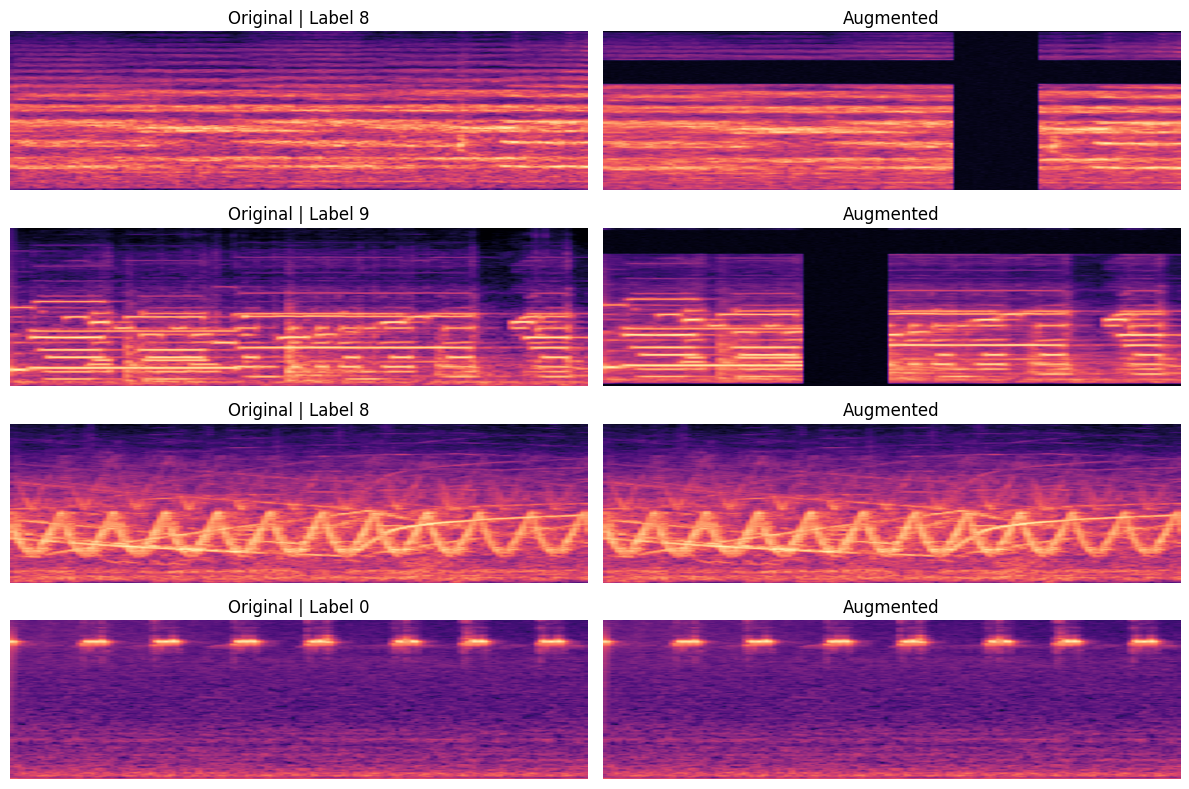

In [6]:
import matplotlib.pyplot as plt

# Sample some paths
sample_df = df.sample(4, random_state=np.random.randint(99999))
sample_paths = sample_df["mel_path"].values
sample_labels = sample_df["classID"].values

# Create two datasets (augmented and not)
ds_plain = create_mel_dataset(sample_paths, sample_labels, batch_size=4, augment=False, shuffle=False)
ds_aug = create_mel_dataset(sample_paths, sample_labels, batch_size=4, augment=True, shuffle=False)

# Load a batch from both
plain_batch = next(iter(ds_plain))
aug_batch = next(iter(ds_aug))

# Plot side-by-side
plt.figure(figsize=(12, 8))
for i in range(4):
    # Original
    plt.subplot(4, 2, 2*i + 1)
    plt.imshow(tf.squeeze(plain_batch[0][i]), cmap="magma", origin="lower", aspect="auto")
    plt.title(f"Original | Label {plain_batch[1][i].numpy()}")
    plt.axis("off")

    # Augmented
    plt.subplot(4, 2, 2*i + 2)
    plt.imshow(tf.squeeze(aug_batch[0][i]), cmap="magma", origin="lower", aspect="auto")
    plt.title(f"Augmented")
    plt.axis("off")

plt.tight_layout()
plt.show()


# Model Architecture

In [6]:
import tensorflow as tf

def attention_block(x, filters):
    """Applies both channel and spatial attention"""
    avg_pool = tf.keras.layers.GlobalAveragePooling2D()(x)
    avg_pool = tf.keras.layers.Reshape((1, 1, filters))(avg_pool)
    avg_pool = tf.keras.layers.Conv2D(filters // 8, (1, 1), activation='relu')(avg_pool)
    avg_pool = tf.keras.layers.Conv2D(filters, (1, 1), activation='sigmoid')(avg_pool)
    x = tf.keras.layers.Multiply()([x, avg_pool])

    spatial = tf.keras.layers.Conv2D(1, (1, 1), activation='sigmoid')(x)
    x = tf.keras.layers.Multiply()([x, spatial])
    return x


def build_model(hp):
    """
    CNN model builder with optional attention and LR scheduling, for Keras Tuner.
    """
    # === Tunable Hyperparams ===
    dropout_rate = hp.Float("dropout", 0.3, 0.6, step=0.1)
    l2_val = hp.Float("l2", 1e-5, 1e-3, sampling="log")
    filters_start = hp.Choice("filters_start", [32, 48, 64])
    depth = hp.Int("depth", 2, 4)
    use_attention = hp.Boolean("use_attention")
    pool_type = hp.Choice("pool_type", ["max", "avg"])
    lr_val = hp.Float("learning_rate", 1e-4, 1e-3, sampling="log")
    lr_schedule = hp.Choice("lr_schedule", ["none", "plateau", "cosine"])

    # === Input ===
    inputs = tf.keras.Input(shape=(256, 150, 1))
    x = inputs
    filters = filters_start

    # === Conv Blocks ===
    for i in range(depth):
        x = tf.keras.layers.Conv2D(filters, (3, 3), padding="same",
                                   kernel_regularizer=tf.keras.regularizers.l2(l2_val))(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.ReLU()(x)

        x = tf.keras.layers.Conv2D(filters, (3, 3), padding="same",
                                   kernel_regularizer=tf.keras.regularizers.l2(l2_val))(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.ReLU()(x)

        if pool_type == "max":
            x = tf.keras.layers.MaxPooling2D((2, 2))(x)
        else:
            x = tf.keras.layers.AveragePooling2D((2, 2))(x)

        filters *= 2

    # === Optional Attention ===
    if use_attention:
        x = attention_block(x, filters // 2)

    # === Head ===
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(128, activation='relu',
                              kernel_regularizer=tf.keras.regularizers.l2(l2_val))(x)
    x = tf.keras.layers.Dropout(dropout_rate)(x)
    outputs = tf.keras.layers.Dense(10, activation='softmax')(x)

    # === LR Scheduler Setup ===
    if lr_schedule == "plateau":
        schedule = tf.keras.optimizers.schedules.ExponentialDecay(
            initial_learning_rate=lr_val,
            decay_steps=1000,
            decay_rate=0.9
        )
    elif lr_schedule == "cosine":
        schedule = tf.keras.optimizers.schedules.CosineDecay(
            initial_learning_rate=lr_val,
            decay_steps=1000
        )
    else:
        schedule = lr_val  # static

    model = tf.keras.Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=schedule),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


# Hyperparameter Tuner - hyperband

In [5]:
import keras_tuner as kt
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping

def run_hyperparameter_tuning(file_paths, labels, max_epochs=20, factor=3, hyperband_iterations=3, project_name="mel_tuning"):
    """
    Runs Keras Tuner Hyperband with stratified split, class weights, and dataset sanity check.
    """
    # === Stratified Split ===
    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
    train_idx, val_idx = next(sss.split(file_paths, labels))
    x_train, y_train = file_paths[train_idx], labels[train_idx]
    x_val, y_val = file_paths[val_idx], labels[val_idx]

    # === Compute Class Weights ===
    class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
    class_weight_dict = {i: w for i, w in enumerate(class_weights)}
    print(f" Class Weights: {class_weight_dict}")

    # === Datasets ===
    train_ds = create_mel_dataset(x_train, y_train, augment=True)
    val_ds = create_mel_dataset(x_val, y_val, augment=False, shuffle=False)

    # === Sanity Check ===
    try:
        xb, yb = next(iter(train_ds))
        print(f"✅ Sanity Check - Batch shape: {xb.shape}, Labels: {yb.numpy()[:5]}")
    except Exception as e:
        print(f"❌ Dataset Sanity Check Failed: {e}")
        return None

    # === Tuner ===
    tuner = kt.Hyperband(
        build_model,
        objective="val_accuracy",
        max_epochs=max_epochs,
        factor=factor,
        hyperband_iterations=hyperband_iterations,
        directory="tuner_results",
        project_name=project_name,
        overwrite=False,
        seed=SEED
    )

    callbacks = [
        EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True)
    ]

    # === Start Tuning ===
    tuner.search(
        train_ds,
        validation_data=val_ds,
        epochs=max_epochs,
        callbacks=callbacks,
        class_weight=class_weight_dict,
        verbose=1
    )

    # === Get Best HP ===
    best_hp = tuner.get_best_hyperparameters(1)[0]
    print("\n Best Hyperparameters:")
    for param in best_hp.values:
        print(f"  {param}: {best_hp.get(param)}")

    return best_hp


# Training 

* with early stoppng patience 3 -> best acc 85.37
* with early stopping patience 10 -> best acc 87.80
* without early stopping with model checkpoint -> best acc ???


 - NOTE: fOLD 3 is best performer in general

In [ ]:
import os
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
# from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.utils import set_random_seed

def train_kfold(file_paths, labels, best_hp, n_splits=5, epochs=30, batch_size=32):
    """
    Trains the model using Stratified K-Fold and logs all results.
    Includes class weighting for imbalance handling.
    """
    set_random_seed(SEED)

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    fold_metrics = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(file_paths, labels)):
        print(f"\n Training Fold {fold + 1}/{n_splits}...")

        x_train, y_train = file_paths[train_idx], labels[train_idx]
        x_val, y_val = file_paths[val_idx], labels[val_idx]

        train_ds = create_mel_dataset(x_train, y_train, augment=True, batch_size=batch_size)
        val_ds = create_mel_dataset(x_val, y_val, augment=False, shuffle=False, batch_size=batch_size)

        # === Quick Validation Check ===
        try:
            train_batch = next(iter(train_ds))
            val_batch = next(iter(val_ds))

            print(f" ✅ train batch: x={train_batch[0].shape}, y={train_batch[1].shape}, dtype={train_batch[0].dtype}")
            print(f" ✅ val batch:   x={val_batch[0].shape}, y={val_batch[1].shape}, dtype={val_batch[0].dtype}")
            print(f" 🎯 train labels sample: {train_batch[1][:5].numpy()}")
            print(f" 🎯 val labels sample:   {val_batch[1][:5].numpy()}")

        except Exception as e:
            print(f"  Error while inspecting batch: {e}")
            continue

        # === Compute class weights ===
        class_weights = compute_class_weight(
            class_weight="balanced",
            classes=np.unique(y_train),
            y=y_train
        )
        class_weight_dict = {i: w for i, w in enumerate(class_weights)}
        print(f"  Class weights: {class_weight_dict}")

        model = build_model(best_hp)

        model_path = f"/kaggle/working/models/fold_{fold + 1}_best_model.keras"
        os.makedirs(os.path.dirname(model_path), exist_ok=True)

        callbacks = [
            # EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True),
            ModelCheckpoint(model_path, monitor='val_accuracy', save_best_only=True, verbose=1)
        ]

        history = model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=epochs,
            callbacks=callbacks,
            class_weight=class_weight_dict,
            verbose=1
        )

        best_acc = max(history.history['val_accuracy'])
        best_loss = min(history.history['val_loss'])

        print(f"   Fold {fold + 1} saved to {model_path}")

        fold_metrics.append({
            "fold": fold + 1,
            "val_accuracy": best_acc,
            "val_loss": best_loss,
            "model_path": model_path
        })

    print("\n Fold Validation Summary:")
    for m in fold_metrics:
        print(f" Fold {m['fold']}: acc={m['val_accuracy']:.4f}, loss={m['val_loss']:.4f} → {m['model_path']}")

    return fold_metrics


In [14]:
def get_mel_paths_and_labels(df, cache_dir):
    """
    Matches cached .npy files with their original labels.
    Returns: (file_paths, labels) as np arrays
    """
    mel_paths = []
    mel_labels = []

    for _, row in df.iterrows():
        mel_path = os.path.join(
            cache_dir,
            os.path.basename(row["file_name"]).replace(".wav", "_mel.npy")
        )
        if os.path.exists(mel_path):
            mel_paths.append(mel_path)
            mel_labels.append(row["classID"])

    return np.array(mel_paths), np.array(mel_labels)

In [ ]:
# Extract zip
zip_path="/kaggle/input/tuner_results_archive.zip"
extract_to="/kaggle/working/tuner_results"
                        
if os.path.exists(zip_path):
    print(" Unpacking tuner archive...")
    shutil.unpack_archive(zip_path, extract_to)
    print(" Archive extracted.")

In [10]:
mel_paths, mel_labels = get_mel_paths_and_labels(df, CACHE_DIR)

best_hp = run_hyperparameter_tuning(
    file_paths=mel_paths,
    labels=mel_labels,
    max_epochs=30,
    factor=3,
    hyperband_iterations=3,
    project_name="mel_tuning"
)


NameError: name 'get_mel_paths_and_labels' is not defined

In [16]:
#Turn tuner file to zip
import shutil

# Path to the folder you want to zip
input_dir = '/kaggle/working/tuner_results'

# Path (without extension) where the .zip will be saved
output_zip = '/kaggle/working/tuner_results_archive'

# Create a ZIP file
shutil.make_archive(output_zip, 'zip', input_dir)

print(f"Created archive at: {output_zip}.zip")


Created archive at: /kaggle/working/tuner_results_archive.zip


In [13]:
# Zip Delete 
import os

file_path = '/kaggle/working/tuner_results_archive.zip'

if os.path.isfile(file_path):
    os.remove(file_path)
    print(f"Deleted: {file_path}")
else:
    print(f"No such file: {file_path}")


Deleted: /kaggle/working/tuner_results_archive.zip


In [7]:
# === Helper: Try Load Tuner Results ===
import os
import shutil
import keras_tuner as kt

def get_best_hp_if_exists(tuner_dir="tuner_results", project_name="mel_tuning"):
    tuner_path = os.path.join(tuner_dir, project_name)
    if os.path.exists(tuner_path):
        print(" Found local tuner results. Loading best hyperparameters...")
        tuner = kt.Hyperband(
            build_model,
            objective="val_accuracy",
            max_epochs=30,
            directory=tuner_dir,
            project_name=project_name,
            seed=SEED
        )

        print("\n Best Hyperparameters:")
        a=tuner.get_best_hyperparameters(1)[0]
        for param in best_hp.values:
            print(f"  {param}: {a.get(param)}")

        return tuner.get_best_hyperparameters(1)[0]
    else:
        print("No local tuner results found.")
        return None


def get_best_hp_from_upload(tuner_dir="/kaggle/input/tuner-results-18-04-25", project_name="mel_tuning"):
    tuner_path = os.path.join(tuner_dir, project_name)
    if os.path.exists(tuner_path):
        print(" Found local tuner results from upload. Loading best hyperparameters...")
        tuner = kt.Hyperband(
            build_model,
            objective="val_accuracy",
            max_epochs=30,
            directory=tuner_dir,
            project_name=project_name,
            seed=SEED
        )
        
        print("\n Best Hyperparameters:")
        a=tuner.get_best_hyperparameters(1)[0]
        for param in best_hp.values:
            print(f"  {param}: {a.get(param)}")
            
        return tuner.get_best_hyperparameters(1)[0]
    else:
        print("No local tuner results found.")
        return None

# === Helper: Try Load From ZIP (Kaggle) ===
def get_best_hp_from_zip(zip_path="/kaggle/input/tuner-results-18-04-25",
                         extract_to="/kaggle/working/tuner_results",
                         project_name="mel_tuning"):
    if os.path.exists(zip_path):
        print(" Unpacking tuner archive...")
        shutil.unpack_archive(zip_path, extract_to)
        print(" Archive extracted.")
        tuner = kt.Hyperband(
            build_model,
            objective="val_accuracy",
            max_epochs=30,
            factor=3,
            hyperband_iterations=3,
            directory=extract_to,
            project_name=project_name,
            overwrite=False,
            seed=SEED
        )
        
        print("\n Best Hyperparameters:")
        a=tuner.get_best_hyperparameters(1)[0]
        for param in best_hp.values:
            print(f"  {param}: {a.get(param)}")
        return tuner.get_best_hyperparameters(1)[0]
    else:
        print(" No tuner archive found.")
        return None


In [ ]:
# === Smart Training Launcher ===
def try_train_if_hp_available(
    mel_paths,
    mel_labels,
    n_splits=5,
    epochs=50,
    batch_size=32,
    project_name="mel_tuning"
):
    best_hp_local = None

    # 1 Check if `best_hp` is already defined in current session
    if "best_hp" in globals() and best_hp is not None:
        print(" Using best_hp from memory.")
        print("\n Best Hyperparameters:")
        for param in best_hp.values:
            print(f"  {param}: {best_hp.get(param)}")

        best_hp_local = best_hp

    # 2 Try loading from local tuner directory (non-Kaggle)
    if best_hp_local is None:
        best_hp_local = get_best_hp_if_exists(project_name=project_name)
        
    # 3 Try loading from upload directory
    if best_hp_local is None:
        best_hp_local = get_best_hp_from_upload(project_name=project_name)

    # 4 Try loading from a ZIP file (for Kaggle ZIP uploads)
    if best_hp_local is None:
        best_hp_local = get_best_hp_from_zip(project_name=project_name)

    # 4 Final check — train or skip
    if best_hp_local is not None:
        print(" Starting K-Fold training with loaded hyperparameters...")
        train_kfold(
            file_paths=mel_paths,
            labels=mel_labels,
            best_hp=best_hp_local,
            n_splits=n_splits,
            epochs=epochs,
            batch_size=batch_size
        )
    else:
        print(" No valid hyperparameters found. Aborting training.")


In [9]:
mel_paths, mel_labels = get_mel_paths_and_labels(df, CACHE_DIR)
try_train_if_hp_available(mel_paths, mel_labels)


NameError: name 'get_mel_paths_and_labels' is not defined

# Inference - Performance Test

In [17]:
import os
import numpy as np
import pandas as pd
import librosa
import tensorflow as tf
from sklearn.metrics import accuracy_score, classification_report
from tensorflow.keras.models import load_model
from tqdm import tqdm

# === Constants ===
SR = 22050
N_MELS = 256
FMAX = 8000
FIXED_TIME_STEPS = 150
TEST_AUDIO_DIR = "/kaggle/input/yldz-teknik-proje-1-train-dataset/Test_Public"
TEST_CSV_PATH = "/kaggle/input/yldz-teknik-proje-1-train-dataset/Test_Public.csv"
CACHE_DIR = "/kaggle/working/test_mel_cache"
MODEL_DIR = "/kaggle/working/models"

os.makedirs(CACHE_DIR, exist_ok=True)

# === Load test metadata ===
df_test = pd.read_csv(TEST_CSV_PATH)
df_test["filepath"] = df_test["file_name"].apply(lambda x: os.path.join(TEST_AUDIO_DIR, x))

# === Cache test mel spectrograms ===
def cache_test_mels(df, cache_dir):
    mel_paths = []

    for _, row in tqdm(df.iterrows(), total=len(df), desc="🔊 Caching test mel spectrograms"):
        wav_path = row["filepath"]
        mel_path = os.path.join(cache_dir, os.path.basename(wav_path).replace(".wav", "_mel.npy"))
        mel_paths.append(mel_path)

        if os.path.exists(mel_path):
            continue

        try:
            y, sr = librosa.load(wav_path, sr=SR)
            mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS, fmax=FMAX)
            mel_db = librosa.power_to_db(mel, ref=np.max)
            mel_db = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-8)
            mel_db = librosa.util.fix_length(mel_db, size=FIXED_TIME_STEPS, axis=1)
            mel_db = np.expand_dims(mel_db, axis=-1)
            np.save(mel_path, mel_db)
        except Exception as e:
            print(f"[ERROR] {wav_path}: {e}")
            mel_paths[-1] = None

    df["mel_path"] = mel_paths
    return df[df["mel_path"].notnull()]

df_test = cache_test_mels(df_test, CACHE_DIR)
print(f"\n Total test samples cached: {len(df_test)}")


🔊 Caching test mel spectrograms: 100%|██████████| 82/82 [00:05<00:00, 14.10it/s]


 Total test samples cached: 82


In [20]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report
from tensorflow.keras.models import load_model

# === Load mels and labels ===
X_test = np.array([np.load(path) for path in df_test["mel_path"]])
y_test = df_test["classID"].values

# === Load Models ===
models = []
model_paths = [os.path.join(MODEL_DIR, f"fold_{i}_best_model.keras") for i in range(1, 6)]

for path in model_paths:
    if os.path.exists(path):
        print(f"  Loaded model: {os.path.basename(path)}")
        models.append(load_model(path))
    else:
        print(f"  Missing model: {os.path.basename(path)}")

# === Predict with each model ===
all_probs = []
for i, model in enumerate(models):
    probs = model.predict(X_test, batch_size=32, verbose=0)
    preds = np.argmax(probs, axis=1)

    acc = accuracy_score(y_test, preds)
    print(f"\n Fold {i+1} Accuracy: {acc:.4f}")
    print(classification_report(y_test, preds, digits=3))

    all_probs.append(probs)

# === Ensemble Prediction: Soft Voting (Confidence Averaging) ===
avg_probs = np.mean(all_probs, axis=0)
ensemble_preds = np.argmax(avg_probs, axis=1)

# === Evaluation ===
ensemble_acc = accuracy_score(y_test, ensemble_preds)
print(f"\n Ensemble Accuracy (Soft Voting): {ensemble_acc:.4f}")
print(classification_report(y_test, ensemble_preds, digits=3))


  Loaded model: fold_1_best_model.keras
  Loaded model: fold_2_best_model.keras
  Loaded model: fold_3_best_model.keras
  Loaded model: fold_4_best_model.keras
  Loaded model: fold_5_best_model.keras

 Fold 1 Accuracy: 0.8049
              precision    recall  f1-score   support

           0      0.714     1.000     0.833        10
           1      1.000     1.000     1.000         3
           2      0.800     0.800     0.800        10
           3      0.583     0.700     0.636        10
           4      1.000     0.400     0.571        10
           5      0.778     0.778     0.778         9
           6      0.800     1.000     0.889         4
           7      0.800     1.000     0.889         8
           8      1.000     0.625     0.769         8
           9      1.000     1.000     1.000        10

    accuracy                          0.805        82
   macro avg      0.848     0.830     0.817        82
weighted avg      0.836     0.805     0.796        82


 Fold 2 Accura

# Google Drive Inference

In [ ]:
# One-Cell Inference Script (Handles 1 or More Models)
!pip install -q librosa tqdm scikit-learn gdown
#=============================================================
import os, shutil, zipfile
import numpy as np
import pandas as pd
import librosa
import tensorflow as tf
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report
from tensorflow.keras.models import load_model
import gdown


SR = 22050
N_MELS = 256
FMAX = 8000
FIXED_TIME_STEPS = 150
BATCH_SIZE = 64

# === Paths ============================================
SECRET_AUDIO_DIR = "dataset/Test_Public"
SECRET_CSV_PATH = "dataset/Test_Public.csv"
#==========================================================
GDRIVE_ZIP_URL = "https://drive.google.com/uc?export=download&id=1Q-UgRMotZ3FgpLE6MpDwdrXfKj5Ge-5A"
MODEL_ZIP_PATH = "/kaggle/working/models_from_drive.zip"
TEMP_MODEL_DIR = "/kaggle/working/_temp_models"
TEMP_CACHE_DIR = "/kaggle/working/_temp_cache"

os.makedirs(TEMP_MODEL_DIR, exist_ok=True)
os.makedirs(TEMP_CACHE_DIR, exist_ok=True)

# Download Model ZIP 
print(" Downloading model ZIP from Google Drive...")
gdown.download(GDRIVE_ZIP_URL, MODEL_ZIP_PATH, quiet=False)

# Unzip 
with zipfile.ZipFile(MODEL_ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(TEMP_MODEL_DIR)
print(" Models unzipped.\n")

# Load Metadata 
df_test = pd.read_csv(SECRET_CSV_PATH)
df_test["filepath"] = df_test["file_name"].apply(lambda x: os.path.join(SECRET_AUDIO_DIR, x))

# Cache Mels 
def cache_test_mels(df, cache_dir):
    mel_paths = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc=" Caching mels"):
        wav_path = row["filepath"]
        mel_path = os.path.join(cache_dir, os.path.basename(wav_path).replace(".wav", "_mel.npy"))
        mel_paths.append(mel_path)
        if os.path.exists(mel_path): continue
        try:
            y, sr = librosa.load(wav_path, sr=SR)
            mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS, fmax=FMAX)
            mel_db = librosa.power_to_db(mel, ref=np.max)
            mel_db = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-8)
            mel_db = librosa.util.fix_length(mel_db, size=FIXED_TIME_STEPS, axis=1)
            mel_db = np.expand_dims(mel_db, axis=-1)
            np.save(mel_path, mel_db)
        except Exception as e:
            print(f"[ERROR] {wav_path}: {e}")
            mel_paths[-1] = None
    df["mel_path"] = mel_paths
    return df[df["mel_path"].notnull()]

df_test = cache_test_mels(df_test, TEMP_CACHE_DIR)
X_test = np.array([np.load(p) for p in df_test["mel_path"]])
y_test = df_test["classID"].values
print(f"\nLoaded {len(X_test)} mel samples.")

# === Load Models ===
models, model_names = [], []
for root, _, files in os.walk(TEMP_MODEL_DIR): 
    for fname in sorted(files):
        if fname.endswith(".keras"):
            fpath = os.path.join(root, fname)
            try:
                models.append(load_model(fpath))
                model_names.append(fname)
                print(f" Loaded: {fname}")
            except Exception as e:
                print(f" Failed to load {fname}: {e}")


# Evaluate Models 
all_probs = []
model_scores = {}

for i, model in enumerate(models):
    print(f"\n Evaluating {model_names[i]}")
    probs = model.predict(X_test, batch_size=BATCH_SIZE, verbose=0)
    preds = np.argmax(probs, axis=1)

    acc = accuracy_score(y_test, preds)
    report = classification_report(y_test, preds, digits=3)
    print(f"   Accuracy: {acc:.4f}")
    print(report)

    all_probs.append(probs)
    model_scores[model_names[i]] = {"accuracy": acc, "report": report}

# If multiple models do Ensemble and Best
if len(models) > 1:
    print("\n Ensemble Voting (Soft)...")
    avg_probs = np.mean(all_probs, axis=0)
    ensemble_preds = np.argmax(avg_probs, axis=1)

    ensemble_acc = accuracy_score(y_test, ensemble_preds)
    ensemble_report = classification_report(y_test, ensemble_preds, digits=3)

    print(f"\n Ensemble Accuracy: {ensemble_acc:.4f}")
    print(ensemble_report)

    model_scores["Ensemble"] = {"accuracy": ensemble_acc, "report": ensemble_report}

    # Best 
    best_model = max(model_scores.items(), key=lambda x: x[1]['accuracy'])
    print(f"\n Best: {best_model[0]} — Accuracy: {best_model[1]['accuracy']:.4f}")
    print(best_model[1]['report'])

# Cleanup 
shutil.rmtree(TEMP_MODEL_DIR)
shutil.rmtree(TEMP_CACHE_DIR)
os.remove(MODEL_ZIP_PATH)
print("\n Cleanup complete. All temporary files removed.")


🔽 Downloading model ZIP from Google Drive...


Downloading...
From (original): https://drive.google.com/uc?export=download&id=1Q-UgRMotZ3FgpLE6MpDwdrXfKj5Ge-5A
From (redirected): https://drive.google.com/uc?export=download&id=1Q-UgRMotZ3FgpLE6MpDwdrXfKj5Ge-5A&confirm=t&uuid=97913e68-8eb0-4d0d-92c3-dc139de23607
To: d:\kaggle\working\models_from_drive.zip
100%|██████████| 52.2M/52.2M [00:07<00:00, 7.13MB/s]


✅ Models unzipped.



🔊 Caching mels: 100%|██████████| 82/82 [00:00<00:00, 16402.75it/s]


✅ Loaded 82 mel samples.


✅ Loaded: fold_3_best_model.keras

📊 Evaluating fold_3_best_model.keras
   Accuracy: 0.8780
              precision    recall  f1-score   support

           0      0.714     1.000     0.833        10
           1      1.000     1.000     1.000         3
           2      0.800     0.800     0.800        10
           3      0.875     0.700     0.778        10
           4      1.000     0.800     0.889        10
           5      1.000     1.000     1.000         9
           6      0.800     1.000     0.889         4
           7      0.889     1.000     0.941         8
           8      1.000     0.625     0.769         8
           9      0.909     1.000     0.952        10

    accuracy                          0.878        82
   macro avg      0.899     0.893     0.885        82
weighted avg      0.894     0.878     0.875        82


🧹 Cleanup complete. All temporary files removed.
